In [ ]:
# cell 1 (UPDATED)
import os
import shutil

# Sesuaikan dengan path folder dataset yang baru selesai kamu download
sumber_dataset = r"C:\Users\User\Downloads\archive (1)" 

target_alert = "dataset/alert"
target_warning = "dataset/warning" # TAMBAHAN: Folder untuk Label 5
target_drowsy = "dataset/drowsy"

# Membuat folder target jika belum ada
os.makedirs(target_alert, exist_ok=True)
os.makedirs(target_warning, exist_ok=True) # TAMBAHAN
os.makedirs(target_drowsy, exist_ok=True)

print("Memulai proses pemisahan dataset...")
berhasil_dipindah = 0

# Berjalan menelusuri setiap folder dan subfolder di dalam hasil ekstrak
for root, dirs, files in os.walk(sumber_dataset):
    for file in files:
        # Ubah nama file ke huruf kecil semua agar seragam
        nama_file_lower = file.lower()
        
        # Mengecek apakah ini file video
        if nama_file_lower.endswith(('.mp4', '.mov', '.avi')):
            path_asal = os.path.join(root, file)
            
            # Mengambil ID partisipan dari nama folder induknya (misal folder "01", "02")
            nama_folder = os.path.basename(root)
            
            # Jika file adalah "0.mov" -> Masukkan ke folder alert
            if nama_file_lower.startswith('0.'):
                nama_baru = f"peserta_{nama_folder}_alert.mov"
                path_tujuan = os.path.join(target_alert, nama_baru)
                shutil.copy2(path_asal, path_tujuan)
                berhasil_dipindah += 1
                
            # Jika file adalah "5.mov" -> Masukkan ke folder warning (TAMBAHAN)
            elif nama_file_lower.startswith('5.'):
                nama_baru = f"peserta_{nama_folder}_warning.mov"
                path_tujuan = os.path.join(target_warning, nama_baru)
                shutil.copy2(path_asal, path_tujuan)
                berhasil_dipindah += 1
                
            # Jika file adalah "10.mov" -> Masukkan ke folder drowsy
            elif nama_file_lower.startswith('10.'):
                nama_baru = f"peserta_{nama_folder}_drowsy.mov"
                path_tujuan = os.path.join(target_drowsy, nama_baru)
                shutil.copy2(path_asal, path_tujuan)
                berhasil_dipindah += 1

print(f"Selesai! Berhasil menyalin dan mengganti nama {berhasil_dipindah} video.")
print("File 5.mov (Setengah Ngantuk) SEKARANG IKUT DIMASUKKAN untuk keperluan Stress Test.")

In [1]:
# cell 2 (UPDATED)
import cv2
import dlib
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from fatigue_detector import FatigueDetector

DATASET_DIR = "dataset"
SHAPE_PREDICTOR_PATH = "shape_predictor_68_face_landmarks.dat"

print("[INFO] Memuat model deteksi wajah Dlib...")
face_detector = dlib.get_frontal_face_detector()
landmark_predictor = dlib.shape_predictor(SHAPE_PREDICTOR_PATH)

(lStart, lEnd) = (42, 48)
(rStart, rEnd) = (36, 42)
(mStart, mEnd) = (48, 68) # TAMBAHAN: Ekstraksi Mulut

print("[INFO] Setup selesai. Sistem siap digunakan.")

[INFO] Memuat model deteksi wajah Dlib...
[INFO] Setup selesai. Sistem siap digunakan.


In [2]:
# cell 3 (UPDATED)
def process_video(video_path, detector_logic):
    cap = cv2.VideoCapture(video_path)
    
    # Reset internal state fatigue_detector
    detector_logic.ear_counter = 0
    detector_logic.warning_counter = 0
    detector_logic.status = 0
    
    final_predicted_status = 0 # Default: Alert (0)
    frame_count = 0
    start_time = time.time()
    
    frame_skip = 3 
    
    while True:
        ret, frame = cap.read()
        if not ret: 
            break
            
        frame_count += 1
        if frame_count % frame_skip != 0:
            continue
            
        h, w = frame.shape[:2]
        new_w = 500
        new_h = int((new_w / w) * h)
        frame_resized = cv2.resize(frame, (new_w, new_h))
        
        gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
        faces = face_detector(gray, 0)
        
        for face in faces:
            shape = landmark_predictor(gray, face)
            landmarks = [(shape.part(i).x, shape.part(i).y) for i in range(68)]
            
            leftEye = landmarks[lStart:lEnd]
            rightEye = landmarks[rStart:rEnd]
            mouth = landmarks[mStart:mEnd]
            
            # Panggil logika baru yang mendukung 3 parameter (EAR, MAR, Status)
            _, _, current_status = detector_logic.check_drowsiness(leftEye, rightEye, mouth)
            
            # Jika mencapai status tertinggi (10 / Drowsy), langsung hentikan video
            if current_status == 10:
                final_predicted_status = 10
                break
            
            # Jika mendeteksi Warning (5), catat tapi tetap lanjutkan video 
            # (Siapa tahu di frame berikutnya dia benar-benar Drowsy)
            elif current_status == 5:
                final_predicted_status = max(final_predicted_status, 5)

        if final_predicted_status == 10:
            break
            
    end_time = time.time()
    cap.release()
    
    processing_time = end_time - start_time
    fps = (frame_count / frame_skip) / processing_time if processing_time > 0 else 0
    
    return final_predicted_status, fps

In [4]:
# cell 4 (FINAL EXECUTION)
import os

detector = FatigueDetector(
    ear_drowsy=0.23, 
    ear_warning=0.25, 
    mar_threshold=0.5, 
    consecutive_frames=9 
)

y_true = []
y_pred = []
fps_list = []

def evaluate_folder(folder_name, true_label):
    print(f"\n=========================================")
    print(f" MEMPROSES DATASET {folder_name.upper()} (Target: {true_label})")
    print(f"=========================================")
    folder_dir = os.path.join(DATASET_DIR, folder_name)
    
    if not os.path.exists(folder_dir):
        print(f"Folder {folder_dir} tidak ditemukan. Melewati...")
        return

    # Sortir agar rapi sesuai urutan peserta
    for filename in sorted(os.listdir(folder_dir)):
        if filename.lower().endswith(('.mp4', '.mov', '.avi')):
            path = os.path.join(folder_dir, filename)
            pred, fps = process_video(path, detector)
            
            y_true.append(true_label)
            y_pred.append(pred)
            fps_list.append(fps)
            
            hasil = "BENAR" if pred == true_label else f"SALAH (Sistem menebak {pred})"
            print(f"Video {filename} -> {hasil} | Speed: {fps:.1f} FPS")

# EKSEKUSI SELURUH 209 VIDEO
evaluate_folder("alert", 0)
evaluate_folder("warning", 5)
evaluate_folder("drowsy", 10)

print("\n[INFO] SELURUH DATASET BERHASIL DIEVALUASI!")


 MEMPROSES DATASET ALERT (Target: 0)
Video peserta_01_alert.mov -> SALAH (Sistem menebak 10) | Speed: 17.8 FPS
Video peserta_02_alert.mov -> SALAH (Sistem menebak 10) | Speed: 21.7 FPS
Video peserta_03_alert.mov -> BENAR | Speed: 17.5 FPS
Video peserta_04_alert.mov -> SALAH (Sistem menebak 5) | Speed: 59.3 FPS
Video peserta_05_alert.mov -> SALAH (Sistem menebak 5) | Speed: 21.9 FPS
Video peserta_06_alert.mov -> SALAH (Sistem menebak 5) | Speed: 41.0 FPS
Video peserta_07_alert.mov -> SALAH (Sistem menebak 10) | Speed: 17.7 FPS
Video peserta_08_alert.mov -> SALAH (Sistem menebak 5) | Speed: 30.2 FPS
Video peserta_09_alert.mov -> SALAH (Sistem menebak 5) | Speed: 18.1 FPS
Video peserta_10_alert.mov -> SALAH (Sistem menebak 10) | Speed: 24.5 FPS
Video peserta_11_alert.mov -> BENAR | Speed: 50.0 FPS
Video peserta_12_alert.mov -> BENAR | Speed: 51.4 FPS
Video peserta_13_alert.mov -> BENAR | Speed: 17.5 FPS
Video peserta_14_alert.mov -> BENAR | Speed: 14.0 FPS
Video peserta_15_alert.mov -> S

KESIMPULAN EVALUASI SISTEM (STRESS TEST)

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

   Alert (0)       0.50      0.28      0.36        47
 Warning (5)       0.28      0.11      0.15        47
 Drowsy (10)       0.40      0.83      0.54        47

    accuracy                           0.40       141
   macro avg       0.39      0.40      0.35       141
weighted avg       0.39      0.40      0.35       141


[PERFORMA SISTEM]
Kecepatan Proses Rata-rata: 29.08 Frames Per Second (FPS)


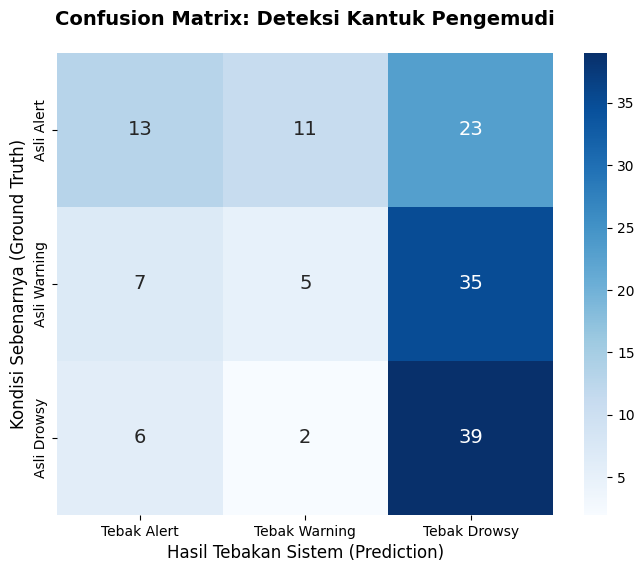

: 

In [ ]:
# cell 5 (UPDATED)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("=========================================")
print("KESIMPULAN EVALUASI SISTEM (STRESS TEST)")
print("=========================================")

# 1. Menampilkan Laporan Metrik
print("\n[CLASSIFICATION REPORT]")
# Parameter labels=[0, 5, 10] WAJIB ditambahkan agar urutan metriknya tidak berantakan
print(classification_report(y_true, y_pred, labels=[0, 5, 10], 
                            target_names=['Alert (0)', 'Warning (5)', 'Drowsy (10)']))

# 2. Menampilkan Rata-rata FPS
avg_fps = np.mean(fps_list) if fps_list else 0
print(f"\n[PERFORMA SISTEM]")
print(f"Kecepatan Proses Rata-rata: {avg_fps:.2f} Frames Per Second (FPS)")

# 3. Menggambar Heatmap Confusion Matrix 3x3
cm = confusion_matrix(y_true, y_pred, labels=[0, 5, 10])
plt.figure(figsize=(8, 6)) # Diperbesar sedikit agar teks 3x3 lebih lega
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tebak Alert', 'Tebak Warning', 'Tebak Drowsy'],
            yticklabels=['Asli Alert', 'Asli Warning', 'Asli Drowsy'],
            annot_kws={"size": 14}) 

plt.title('Confusion Matrix: Deteksi Kantuk Pengemudi', pad=20, size=14, weight='bold')
plt.ylabel('Kondisi Sebenarnya (Ground Truth)', size=12)
plt.xlabel('Hasil Tebakan Sistem (Prediction)', size=12)
plt.show()

In [3]:
# cell 6 (3D GRID SEARCH)
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score
from fatigue_detector import FatigueDetector

DATASET_DIR = "dataset"
ear_grid = [0.21, 0.23, 0.24] 
frame_grid = [5, 9, 11] 
mar_grid = [0.5, 0.6, 0.7] # Grid tambahan untuk MAR

print("=========================================")
print("MEMULAI 3D GRID SEARCH (STRATEGI: MAX RECALL)")
print("=========================================")

alert_dir = os.path.join(DATASET_DIR, "alert")
drowsy_dir = os.path.join(DATASET_DIR, "drowsy")

# MENGGUNAKAN SLICING [:5] UNTUK MENGAMBIL 5 VIDEO SAJA PER KELAS
alert_files = [os.path.join(alert_dir, f) for f in os.listdir(alert_dir) if f.lower().endswith(('.mp4', '.mov'))][:5]
drowsy_files = [os.path.join(drowsy_dir, f) for f in os.listdir(drowsy_dir) if f.lower().endswith(('.mp4', '.mov'))][:5]

best_recall = -1 
# TAMBAHAN: Masukkan 'mar' ke dalam dictionary pencatatan awal
best_params = {'ear': 0, 'mar': 0, 'frames': 0, 'acc': 0, 'prec': 0, 'rec': 0}

kombinasi_ke = 1
# TAMBAHAN: Kalikan dengan panjang mar_grid agar total eksperimen menjadi 27
total_kombinasi = len(ear_grid) * len(frame_grid) * len(mar_grid)

# 3D LOOP: Mencari kombinasi EAR, MAR, dan Frames
for ear in ear_grid:
    for mar in mar_grid: # TAMBAHAN: Loop untuk MAR
        for frames in frame_grid:
            print(f"\n[Eksperimen {kombinasi_ke}/{total_kombinasi}] Menguji EAR: {ear} | MAR: {mar} | Frames: {frames}...")
            
            # TAMBAHAN: Ganti mar_threshold=0.6 menjadi mar_threshold=mar
            detector = FatigueDetector(ear_drowsy=ear, ear_warning=ear+0.02, mar_threshold=mar, consecutive_frames=frames)
            
            y_true_gs = []
            y_pred_gs = []
            
            for filepath in alert_files:
                pred, _ = process_video(filepath, detector) 
                y_true_gs.append(0)
                y_pred_gs.append(pred)
                
            for filepath in drowsy_files:
                pred, _ = process_video(filepath, detector)
                y_true_gs.append(10)
                y_pred_gs.append(pred)
                
            # Paksakan evaluasi biner: Ngantuk = 10, selain itu = 0 (Aman)
            y_true_biner = [1 if y == 10 else 0 for y in y_true_gs]
            y_pred_biner = [1 if y == 10 else 0 for y in y_pred_gs]
                
            acc = accuracy_score(y_true_biner, y_pred_biner)
            prec = precision_score(y_true_biner, y_pred_biner, zero_division=0)
            rec = recall_score(y_true_biner, y_pred_biner, zero_division=0)
            
            print(f"Hasil -> Recall: {rec*100:.1f}% | Precision: {prec*100:.1f}% | Accuracy: {acc*100:.1f}%")
            
            # Logika Kemenangan (Pencatatan parameter terbaik, termasuk MAR)
            if rec > best_recall:
                best_recall = rec
                best_params = {'ear': ear, 'mar': mar, 'frames': frames, 'acc': acc, 'prec': prec, 'rec': rec}
            elif rec == best_recall and prec > best_params['prec']:
                best_params = {'ear': ear, 'mar': mar, 'frames': frames, 'acc': acc, 'prec': prec, 'rec': rec}
                
            kombinasi_ke += 1

print("\n" + "="*50)
print("PENCARIAN SELESAI (STRATEGI RECALL)")
print("="*50)
print(f"EAR Threshold Kritis  : {best_params['ear']}")
print(f"MAR Threshold Kritis  : {best_params['mar']}") # Menampilkan pemenang MAR
print(f"Consecutive Frames    : {best_params['frames']}")
print(f"Recall (Prioritas)    : {best_params['rec']*100:.1f}%")
print(f"Precision             : {best_params['prec']*100:.1f}%")
print("="*50)

MEMULAI 3D GRID SEARCH (STRATEGI: MAX RECALL)

[Eksperimen 1/27] Menguji EAR: 0.21 | MAR: 0.5 | Frames: 5...
Hasil -> Recall: 80.0% | Precision: 57.1% | Accuracy: 60.0%

[Eksperimen 2/27] Menguji EAR: 0.21 | MAR: 0.5 | Frames: 9...
Hasil -> Recall: 60.0% | Precision: 100.0% | Accuracy: 80.0%

[Eksperimen 3/27] Menguji EAR: 0.21 | MAR: 0.5 | Frames: 11...
Hasil -> Recall: 40.0% | Precision: 100.0% | Accuracy: 70.0%

[Eksperimen 4/27] Menguji EAR: 0.21 | MAR: 0.6 | Frames: 5...
Hasil -> Recall: 80.0% | Precision: 57.1% | Accuracy: 60.0%

[Eksperimen 5/27] Menguji EAR: 0.21 | MAR: 0.6 | Frames: 9...
Hasil -> Recall: 60.0% | Precision: 100.0% | Accuracy: 80.0%

[Eksperimen 6/27] Menguji EAR: 0.21 | MAR: 0.6 | Frames: 11...
Hasil -> Recall: 40.0% | Precision: 100.0% | Accuracy: 70.0%

[Eksperimen 7/27] Menguji EAR: 0.21 | MAR: 0.7 | Frames: 5...
Hasil -> Recall: 80.0% | Precision: 57.1% | Accuracy: 60.0%

[Eksperimen 8/27] Menguji EAR: 0.21 | MAR: 0.7 | Frames: 9...
Hasil -> Recall: 60.0% |